# A/B-тест Cookie Cats: разбираюсь глубже, чем стандартный туториал

Cookie Cats — известный учебный датасет по A/B-тестам (его разбирают на DataCamp и на
Kaggle). Обычный разбор выглядит так: сравнили retention между группами, посчитали
p-value, сделали вывод. Я решил пойти дальше и специально проверить то, что в типовых
разборах почти не встречается — заодно закрывая для себя пробел по статистике и A/B-
тестам, который до этого был только в теории.

**Что тестировали.** В игре был шлюз (принудительная пауза) на уровне 30. Часть игроков
случайно попала в группу, где шлюз перенесли на уровень 40. Смотрим на `retention_1` —
вернулся ли игрок через день, и `retention_7` — вернулся ли через неделю.

**План:**
1. Проверка данных
2. Проверка, что группы вообще разделили честно (SRM)
3. Сколько игроков нужно, чтобы что-то заметить (power / MDE)
4. Сами тесты — с поправкой на то, что метрик две
5. Метрика вовлечённости
6. Разбивка по сегментам — тут нашлось самое интересное
7. Bootstrap для перепроверки
8. Что могло пойти не так в этом анализе
9. Вывод


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower

sns.set_style('whitegrid')
np.random.seed(42)

df = pd.read_csv('cookie_cats.csv')
df.head()


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## 1. Проверка данных

Перед тем как что-то тестировать — смотрю на пропуски, дубликаты и выбросы.

In [2]:
print("Строк:", len(df))
print("Пропуски:", df.isnull().sum().sum())
print("Дубликаты userid:", df['userid'].duplicated().sum())
df['version'].value_counts()


Строк: 90189
Пропуски: 0
Дубликаты userid: 0


version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

In [3]:
df['sum_gamerounds'].sort_values(ascending=False).head(5)


57702    49854
7912      2961
29417     2640
43671     2438
48188     2294
Name: sum_gamerounds, dtype: int64

Один игрок сыграл 49 854 раунда — намного больше всех остальных (следующий результат —
2 961). Это выброс, и его стоит убрать из расчётов по количеству раундов ниже (раздел 5
и 6), иначе он один утащит за собой среднее. На `retention_1`/`retention_7` он не
влияет — это просто True/False, выброс тут ни при чём.

## 2. Разделили ли группы честно (SRM)

Прежде чем сравнивать метрики, стоит проверить, что рандомизация вообще сработала как
надо — то есть что группы разделили примерно поровну. Если тут что-то не так,
дальнейшие тесты можно не проводить: результат всё равно будет ненадёжным. Ожидаем
деление 50/50, проверяю хи-квадрат тестом.

In [4]:
n_30 = (df.version == 'gate_30').sum()
n_40 = (df.version == 'gate_40').sum()
total = n_30 + n_40

chi2, p_srm = stats.chisquare([n_30, n_40], [total/2, total/2])

print(f"gate_30: {n_30} ({n_30/total:.2%})")
print(f"gate_40: {n_40} ({n_40/total:.2%})")
print(f"chi2 = {chi2:.3f}, p-value = {p_srm:.4f}")


gate_30: 44700 (49.56%)
gate_40: 45489 (50.44%)
chi2 = 6.902, p-value = 0.0086


Разница небольшая (49.6% / 50.4%), но при обычном пороге 0.05 она формально значима.
Погуглив эту тему, я узнал, что для проверки честности разделения на группы (это
называется Sample Ratio Mismatch, SRM) на практике часто берут более строгий порог —
где-то 0.01, где-то 0.001, единого стандарта нет. При 0.001 наш результат прошёл бы
проверку спокойно, при 0.01 — уже нет.

Честно: я не могу здесь однозначно сказать «всё в порядке» или «данные не годятся» —
для точного ответа нужен доступ к логам самого распределения пользователей по группам,
которого у меня нет. Дальше иду с этой оговоркой в уме, а не тихо игнорирую её.

## 3. Сколько нужно данных, чтобы вообще что-то заметить

Здесь я задался вопросом: а если разница между группами маленькая — увидим ли мы её
вообще при таком количестве игроков? Это называется MDE (minimum detectable effect) —
минимальный эффект, который тест способен поймать с вероятностью 80% при заданном
уровне значимости.

Дальше в разделе 4 я использую поправку на две метрики (об этом там подробнее), поэтому
считаю MDE сразу под тот же скорректированный порог 0.025, чтобы сравнение было
честным, а не «MDE при одних условиях, тест — при других».

In [5]:
def mde_in_pp(baseline_rate, n_per_group, alpha=0.05, power=0.8):
    # переводим эффект из статистических единиц в проценты, понятные бизнесу
    power_calc = NormalIndPower()
    h = power_calc.solve_power(effect_size=None, nobs1=n_per_group,
                                alpha=alpha, power=power, ratio=1.0)
    p2 = np.sin(np.arcsin(np.sqrt(baseline_rate)) - h/2) ** 2
    return abs(p2 - baseline_rate) * 100

n_avg = (n_30 + n_40) / 2
for metric in ['retention_1', 'retention_7']:
    baseline = df[df.version == 'gate_30'][metric].mean()
    mde = mde_in_pp(baseline, n_avg, alpha=0.025)
    print(f"{metric}: базовый уровень {baseline:.2%}, минимально заметный эффект ≈ {mde:.2f} п.п.")


retention_1: базовый уровень 44.82%, минимально заметный эффект ≈ 1.02 п.п.
retention_7: базовый уровень 19.02%, минимально заметный эффект ≈ 0.80 п.п.


Запоминаю эти два числа — пригодятся в разделе 4, когда буду смотреть, значим ли
результат сам по себе, или просто выборка маловата для такого маленького эффекта.

## 4. Сами тесты — с поправкой на две метрики

Тестирую сразу `retention_1` и `retention_7` на одних и тех же данных. Если проверять
каждую по отдельности с порогом 0.05, суммарный шанс случайно найти "значимость" хотя
бы в одной из двух выше заявленных 5%. Поэтому здесь беру более строгий порог для
каждой метрики — 0.05 / 2 = 0.025 (поправка Бонферрони, самый простой вариант такой
поправки).

In [6]:
alpha_corrected = 0.05 / 2

rows = []
for metric in ['retention_1', 'retention_7']:
    succ_30 = df[df.version == 'gate_30'][metric].sum()
    succ_40 = df[df.version == 'gate_40'][metric].sum()

    z, p = proportions_ztest([succ_30, succ_40], [n_30, n_40])
    rate_30, rate_40 = succ_30/n_30, succ_40/n_40
    ci_30 = proportion_confint(succ_30, n_30, method='wilson')
    ci_40 = proportion_confint(succ_40, n_40, method='wilson')

    rows.append(dict(metric=metric, rate_30=rate_30, rate_40=rate_40,
                      diff_pp=(rate_30-rate_40)*100, p=p,
                      ci_30_low=ci_30[0], ci_30_high=ci_30[1],
                      ci_40_low=ci_40[0], ci_40_high=ci_40[1],
                      significant=p < alpha_corrected))

res = pd.DataFrame(rows)
res[['metric', 'rate_30', 'rate_40', 'diff_pp', 'p', 'significant']]


,metric,rate_30,rate_40,diff_pp,p,significant
0,retention_1,0.448188,0.442283,0.590517,0.074410,False
1,retention_7,0.190201,0.182000,0.820130,0.001554,True


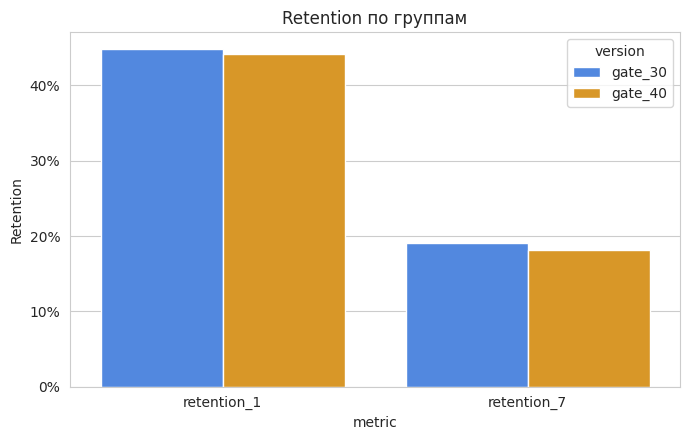

In [7]:
plot_df = pd.DataFrame({
    'metric': ['retention_1', 'retention_1', 'retention_7', 'retention_7'],
    'version': ['gate_30', 'gate_40', 'gate_30', 'gate_40'],
    'rate': [res.loc[0,'rate_30'], res.loc[0,'rate_40'], res.loc[1,'rate_30'], res.loc[1,'rate_40']],
})

plt.figure(figsize=(7, 4.5))
ax = sns.barplot(data=plot_df, x='metric', y='rate', hue='version', palette=['#3B82F6', '#F59E0B'])
ax.set_ylabel('Retention')
ax.set_title('Retention по группам')
ax.yaxis.set_major_formatter(lambda x, _: f'{x:.0%}')
plt.tight_layout()
plt.show()


**Что получилось:**

- `retention_1`: разница 0.59 п.п., p ≈ 0.074. Не проходит даже обычный порог 0.05, тем
  более скорректированный 0.025. И наблюдаемая разница (0.59 п.п.) меньше, чем MDE из
  раздела 3 (≈1.02 п.п.) — то есть при таком размере выборки этот тест физически не мог
  надёжно поймать эффект такого размера. Вывод не «эффекта нет», а «здесь не хватило
  данных, чтобы сказать точно».
- `retention_7`: разница 0.82 п.п., p ≈ 0.0016 — проходит даже скорректированный порог.
  Наблюдаемая разница чуть выше MDE (≈0.80 п.п.), но с очень небольшим запасом. Это
  реальный результат, но не «стопроцентно железный» — граница узкая.

Направление в обоих случаях одинаковое — `gate_40` хуже. Но говорить, что просели обе
метрики, было бы преувеличением: устойчиво это видно только на retention_7.

## 5. Метрика вовлечённости

Отдельно посмотрел на `sum_gamerounds` — не потому что жду, что она «должна остаться
неизменной» (перенос шлюза вполне может законно повлиять на то, сколько раундов
успевает сыграть человек), а просто чтобы понять общую картину. Распределение сильно
скошено (много игроков с малым числом раундов, немного с большим), поэтому вместо
t-теста использую тест Манна-Уитни — он сравнивает не средние, а то, у кого в целом
значения выше.

In [8]:
df_clean = df[df.sum_gamerounds < df.sum_gamerounds.max()].copy()  # без выброса

print(df_clean.groupby('version')['sum_gamerounds'].median())

_, p_mw = stats.mannwhitneyu(
    df_clean[df_clean.version == 'gate_30']['sum_gamerounds'],
    df_clean[df_clean.version == 'gate_40']['sum_gamerounds']
)
print(f"p-value = {p_mw:.4f}")


version
gate_30    17.0
gate_40    16.0
Name: sum_gamerounds, dtype: float64
p-value = 0.0509


p ≈ 0.05 — прямо на границе. Ничего критичного не произошло, направление то же, что и
в retention (gate_30 чуть выше), но я бы не стал делать из этого отдельный громкий
вывод.

## 6. Разбивка по сегментам — здесь нашлось самое интересное

Средний эффект по всем игрокам — это одна цифра на всех. Но что, если она скрывает
разную картину у разных типов игроков? Разделил всех на 4 группы по вовлечённости
(квартили по `sum_gamerounds`, без выброса) и посмотрел на retention_7 в каждой
отдельно.

In [9]:
df_clean['engagement'] = pd.qcut(
    df_clean['sum_gamerounds'].rank(method='first'), 4,
    labels=['мало играют', 'ниже среднего', 'выше среднего', 'много играют']
)

seg = df_clean.groupby(['engagement', 'version'])['retention_7'].mean().unstack()
seg['diff_pp'] = (seg['gate_30'] - seg['gate_40']) * 100

seg_p = []
for group in seg.index:
    sub = df_clean[df_clean.engagement == group]
    s30 = sub[sub.version == 'gate_30']['retention_7'].sum()
    s40 = sub[sub.version == 'gate_40']['retention_7'].sum()
    n30g = (sub.version == 'gate_30').sum()
    n40g = (sub.version == 'gate_40').sum()
    _, p = proportions_ztest([s30, s40], [n30g, n40g])
    seg_p.append(p)
seg['p_value'] = seg_p
seg


version,gate_30,gate_40,diff_pp,p_value
engagement,,,,
мало играют,0.011619,0.012228,-0.060844,0.674028
ниже среднего,0.039397,0.039021,0.037553,0.884508
выше среднего,0.147158,0.131918,1.524037,0.000968
много играют,0.566319,0.541016,2.530235,0.000133


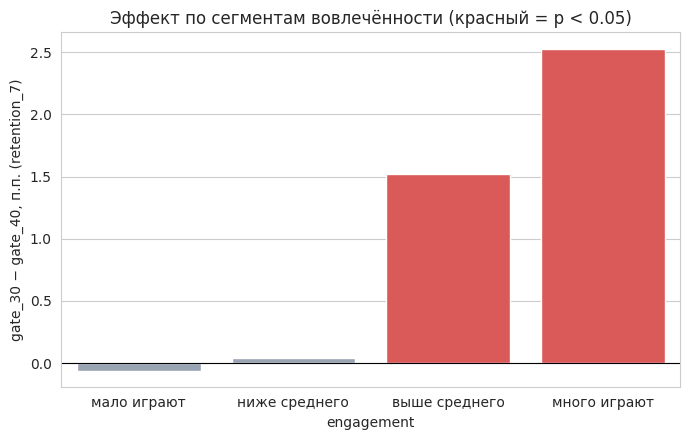

In [10]:
plt.figure(figsize=(7, 4.5))
colors = ['#94A3B8' if p >= 0.05 else '#EF4444' for p in seg['p_value']]
x_labels = seg.index.astype(str)
ax = sns.barplot(x=x_labels, y=seg['diff_pp'], hue=x_labels, palette=colors, legend=False)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('gate_30 − gate_40, п.п. (retention_7)')
ax.set_title('Эффект по сегментам вовлечённости (красный = p < 0.05)')
plt.tight_layout()
plt.show()


У игроков, которые играют мало, разницы между группами почти нет (p = 0.67 и 0.88 —
случайный шум). А у тех, кто играет много, разница не просто есть, а в 3 раза больше
среднего — 2.53 п.п. вместо 0.82 п.п. в среднем по всем.

То есть перенос шлюза почти не задевает случайных игроков, зато заметно бьёт по
retention у самых активных — а это как раз те, кто приносит игре больше всего ценности.
Ни в одном из публичных разборов этого датасета, которые я смотрел, такого разбиения не
было — там всё сводится к одному среднему числу на всех.

Оговорка на будущее: я разбил на сегменты уже после того, как увидел данные, а не
заранее. Это значит, что находку стоит считать «интересной гипотезой, которую нашёл»,
а не «доказанным фактом» — правильнее было бы перепроверить её на новых данных,
заранее решив, что буду смотреть именно на этот разрез.

## 7. Bootstrap — проверяю тем же результат другим способом

Тест из раздела 4 предполагает определённую форму распределения. Хочу убедиться, что
вывод не зависит от этого допущения — для этого прогоняю простой bootstrap: много раз
пересобираю выборку со случайным повторным выбором и смотрю на разброс результата.

In [11]:
r30 = df[df.version == 'gate_30']['retention_7'].values
r40 = df[df.version == 'gate_40']['retention_7'].values

boot_diffs = np.empty(10000)
for i in range(10000):
    boot_diffs[i] = (np.random.choice(r30, len(r30), replace=True).mean()
                      - np.random.choice(r40, len(r40), replace=True).mean())

ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
print(f"95% доверительный интервал разницы: [{ci_low*100:.2f}, {ci_high*100:.2f}] п.п.")
print(f"Доля прогонов с разницей больше нуля: {(boot_diffs > 0).mean():.2%}")


95% доверительный интервал разницы: [0.32, 1.32] п.п.
Доля прогонов с разницей больше нуля: 99.92%


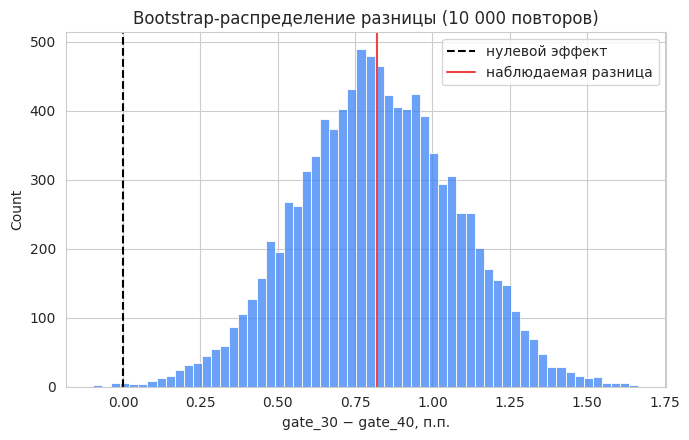

In [12]:
plt.figure(figsize=(7, 4.5))
sns.histplot(boot_diffs*100, bins=60, color='#3B82F6')
plt.axvline(0, color='black', linestyle='--', label='нулевой эффект')
plt.axvline((r30.mean()-r40.mean())*100, color='#EF4444', label='наблюдаемая разница')
plt.xlabel('gate_30 − gate_40, п.п.')
plt.title('Bootstrap-распределение разницы (10 000 повторов)')
plt.legend()
plt.tight_layout()
plt.show()


Интервал не пересекает ноль, и почти все 10 000 прогонов показывают разницу в одну и
ту же сторону. Другим методом, без предположений о форме распределения, получаю тот же
вывод, что и в разделе 4 — это хорошо, значит результат не артефакт конкретного теста.

## 8. Что могло пойти не так в этом анализе

Хочу честно перечислить слабые места, а не только показать красивые графики:

- **SRM не разрешён однозначно** (раздел 2) — по одному порогу проходит, по другому нет.
  Без доступа к логам распределения пользователей это не закрыть до конца.
- **retention_7 значим, но впритык** — наблюдаемый эффект превышает MDE совсем немного
  (0.82 против 0.80 п.п.). Я бы не стал принимать по этому одному прогону решение,
  которое сложно отменить.
- **Находка по сегментам — это гипотеза, а не доказанный факт** (раздел 6), потому что
  сегменты я выбрал уже после того, как посмотрел на данные.
- **Метрика в разделе 5 — не строгий guardrail**, а просто наблюдение сбоку, я специально
  не называю её «признаком поломки».
- Ещё: я поправил порог только под 2 метрики из раздела 4, но дальше в разделе 6
  проверял уже 4 сегмента отдельно — по-хорошему, для полной строгости стоило бы
  учитывать и это тоже (по факту находка всё равно держится даже с более строгой
  поправкой, но явно это не проговорить было бы нечестно).


## 9. Вывод

- `retention_1` — эффекта надёжно не увидели, но и не доказали, что его нет: выборки не
  хватило.
- `retention_7` — статистически значимое снижение при переносе шлюза на уровень 40,
  подтверждается и обычным тестом, и bootstrap-ом, но граница узкая, не «с большим
  запасом».
- Главное наблюдение: этот эффект почти весь приходится на самых вовлечённых игроков —
  у случайных игроков его почти нет.

**Мой вывод как аналитика:** переносить шлюз на уровень 40 не стоит, особенно с учётом
того, что сильнее всего страдают самые ценные игроки. Но перед тем как закрывать
вопрос окончательно, я бы предложил перепроверить результат на новых данных отдельным
тестом, где сегментация по вовлечённости заявлена заранее, а не найдена постфактум —
именно потому что нынешний результат значим, но не с большим запасом.